# Análisis Exploratorio de Datos (EDA)
## Base de Trabajo de Grado — Empleados Colombia (Permanentes)

Este notebook realiza un análisis exploratorio exhaustivo sobre la base de datos de empleados. El objetivo es comprender la estructura, distribución, calidad y relaciones entre las variables del dataset, con foco en la rotación de personal.

**Secciones:**
1. Carga de datos y librerías
2. Inspección general del dataset
3. Análisis de calidad de datos (nulos, duplicados, tipos)
4. Ingeniería de variables derivadas
5. Análisis univariado — Variables categóricas
6. Análisis univariado — Variables numéricas
7. Análisis bivariado
8. Análisis de correlaciones
9. Análisis temporal (antigüedad y tendencias)
10. Análisis de rotación (turnover)
11. Resumen de hallazgos clave

---
## 1. Carga de datos y librerías

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [28]:
import os

while os.path.basename(os.getcwd()) != "tesis_maestria":
    os.chdir("..")
 
os.getcwd()

'c:\\Users\\karen\\OneDrive\\Documentos\\maestria\\tesis_maestria'

In [29]:
df = pd.read_excel("data\Base_Trabajo_Grado_fin.xlsx")
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

Dataset cargado: 5792 filas × 40 columnas


,Employee Code,Termination Code,Hours/ Week,Currency Code,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Job Level,Location Description,Type Location,Contract Type,Exchange Rate,Type,Termination Reason,Termination Type,Target Bonus %,Non Exempt,Active Employee,Hire Date,Termination Date,Target Equity %,Standardized_Salary,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed,Position vs Estimated Median,AGE,CPI,Minimum wage
0,EMP_00001,J,48,COP,3,3,3,4,4,4,N,Cargo 1,Male,Common Law,CLUB OPERATIONS,Merchandising & Inventory,7,LOC_01,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2011-06-20,2013-09-27 00:00:00,0.0000,0.1556,N,Inactive,Inactive,Cargo 342,Yes,NaN,33.0000,0.0194,589500
1,EMP_00002,NaN,44,COP,0,0,0,4,4,4,N,Cargo 2,Male,Married,CLUB OPERATIONS,Fresh & Food Operations,5,LOC_02,Club,Full Time,3765.9200,C,NaN,Unknown,0.0000,Non Exempt,Y,2011-07-15,00:00:00,0.0000,0.0905,Y,EMP_01989,Fresh & Food Operations,Cargo 37,Yes,0.8280,38.0000,0.0510,1423500
2,EMP_00003,J,48,COP,0,0,0,4,4,4,N,Cargo 3,Male,Common Law,CLUB OPERATIONS,Member-Facing Operations,7,LOC_01,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2011-07-11,2014-08-27 00:00:00,0.0000,0.1779,N,Inactive,Inactive,Cargo 342,Yes,NaN,29.0000,0.0366,616000
3,EMP_00004,I,48,COP,2,2,2,4,4,4,N,Cargo 4,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,LOC_01,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Non Exempt,N,2012-05-28,2013-04-15 00:00:00,0.0000,-0.2400,N,Inactive,Inactive,Cargo 342,Yes,NaN,27.0000,0.0194,589500
4,EMP_00005,E,48,COP,0,0,0,4,4,4,N,Cargo 5,Female,Married,CLUB OPERATIONS,Finance & Administrative Support,5,LOC_01,Club,Full Time,3698.6000,C,Personal** DO NOT USE** (Vol),Voluntary,0.0000,Non Exempt,N,2012-05-30,2015-07-09 00:00:00,0.0000,-0.1289,N,Inactive,Inactive,Cargo 342,Yes,NaN,33.0000,0.0677,644350
5,EMP_00006,E,48,COP,0,0,0,4,4,4,N,Cargo 6,Male,Single,CLUB OPERATIONS,Member-Facing Operations,2,LOC_01,Club,Full Time,3001.5000,C,Personal** DO NOT USE** (Vol),Voluntary,0.0000,Non Exempt,N,2012-06-11,2014-10-15 00:00:00,0.0000,-0.3824,N,Inactive,Inactive,Cargo 342,Yes,NaN,32.0000,0.0366,616000
6,EMP_00007,I,48,COP,0,0,0,4,4,4,N,Cargo 6,Female,Married,CLUB OPERATIONS,Member-Facing Operations,2,LOC_01,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Non Exempt,N,2012-06-11,2014-02-18 00:00:00,0.0000,-0.3824,N,Inactive,Inactive,Cargo 342,Yes,NaN,23.0000,0.0366,616000
7,EMP_00008,I,48,COP,2,2,2,4,4,4,N,Cargo 7,Male,Single,CLUB OPERATIONS,Member-Facing Operations,4,LOC_01,Club,Full Time,3001.5000,C,Insubordination (Involuntary),Involuntary,0.0000,Exempt,N,2012-06-11,2013-06-01 00:00:00,0.0000,-0.3141,N,Inactive,Inactive,Cargo 342,Yes,NaN,22.0000,0.0194,589500
8,EMP_00009,J,48,COP,1,1,1,4,4,4,N,Cargo 7,Female,Married,CLUB OPERATIONS,Member-Facing Operations,4,LOC_01,Club,Full Time,3001.5000,C,Violation of Policy (Involun),Involuntary,0.0000,Non Exempt,N,2012-06-11,2013-07-22 00:00:00,0.0000,-0.3141,N,Inactive,Inactive,Cargo 342,Yes,NaN,35.0000,0.0194,589500
9,EMP_00010,NaN,44,COP,1,0,0,4,4,4,N,Cargo 8,Male,Single,CLUB OPERATIONS,Member-Facing Operations,5,LOC_01,Club,Full Time,3765.9200,C,NaN,Unknown,0.0000,Non Exempt,Y,2012-06-11,00:00:00,0.0000,0.0905,Y,EMP_00185,Leadership,Cargo 13,Yes,0.8280,47.0000,0.0510,1423500


---
## 2. Inspección general del dataset

In [30]:
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print('Columnas y tipos de datos:')
print('-'*60)
df.info()

INFORMACIÓN GENERAL DEL DATASET
Filas: 5792
Columnas: 40
Columnas y tipos de datos:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Employee Code                  5792 non-null   object        
 1   Termination Code               3897 non-null   object        
 2   Hours/ Week                    5792 non-null   int64         
 3   Currency Code                  5792 non-null   object        
 4   English Reading Lvl            5792 non-null   int64         
 5   English Spoken Lvl             5792 non-null   int64         
 6   English Writing Lvl            5792 non-null   int64         
 7   Spanish Reading Lvl            5792 non-null   int64         
 8   Spanish Spoken Lvl             5792 non-null   int64         
 9   Spanis

In [31]:
print('Estadísticas descriptivas — Variables numéricas:')
df.describe()

Estadísticas descriptivas — Variables numéricas:


,Hours/ Week,English Reading Lvl,English Spoken Lvl,English Writing Lvl,Spanish Reading Lvl,Spanish Spoken Lvl,Spanish Writing Lvl,Job Level,Exchange Rate,Target Bonus %,Hire Date,Target Equity %,Standardized_Salary,Position vs Estimated Median,AGE,CPI,Minimum wage
count,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792.0000,5792,5792.0000,5792.0000,4369.0000,5791.0000,5792.0000,5792.0000
mean,45.7536,0.6221,0.6117,0.6269,3.0570,3.0566,3.0471,3.1039,3695.4444,0.0043,2019-07-31 18:51:27.845304064,0.0017,0.0000,0.9616,31.4763,0.0580,1104431.3983
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2705.7500,0.0000,1998-11-02 00:00:00,0.0000,-0.4802,0.3440,0.0000,0.0161,589500.0000
25%,44.0000,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,2.0000,3421.0550,0.0000,2016-03-17 18:00:00,0.0000,-0.3060,0.8436,26.0000,0.0510,828116.0000
50%,48.0000,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,2.0000,3765.9200,0.0000,2020-03-02 00:00:00,0.0000,-0.1810,0.9166,30.0000,0.0510,1160000.0000
75%,48.0000,1.0000,1.0000,1.0000,4.0000,4.0000,4.0000,4.0000,3909.5125,0.0000,2023-01-23 00:00:00,0.0000,-0.0502,0.9596,36.0000,0.0575,1423500.0000
max,48.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,16.0000,5104.0000,0.3000,2025-12-19 00:00:00,0.4000,43.4621,154.2114,67.0000,0.1312,1423500.0000
std,4.3370,1.2394,1.2289,1.2477,1.6872,1.6875,1.6919,1.9805,457.4823,0.0271,NaN,0.0159,1.0000,2.3237,7.4749,0.0269,302192.8304


In [32]:
print('Estadísticas descriptivas — Variables categóricas:')
df.describe(include='object')

Estadísticas descriptivas — Variables categóricas:


,Employee Code,Termination Code,Currency Code,Union,Employee Job ID,Gender,Marital Status,Area,Grouped Department Name,Location Description,Type Location,Contract Type,Type,Termination Reason,Termination Type,Non Exempt,Active Employee,Termination Date,Active Supervisor,Supervisor Code,Gropued Supervisor Department,Supervisor Job ID,Probation Period Completed
count,5792,3897,5792,5036,5792,5792,5791,5792,5792,5792,5792,5792,5792,3897,5792,5792,5792,5792,5792,5792,5792,5792,5792
unique,5792,34,2,3,341,3,8,12,13,14,4,2,4,34,3,2,2,2123,2,354,15,130,2
top,EMP_00001,B,COP,N,Cargo 31,Male,Single,CLUB OPERATIONS,Member-Facing Operations,LOC_08,Club,Full Time,C,Better Job Opp (Voluntary),Voluntary,Non Exempt,N,00:00:00,Y,Inactive,Inactive,Cargo 342,Yes
freq,1,663,5780,5030,621,3482,3510,5067,1620,814,5003,5590,5003,663,2021,2905,3897,1895,3924,1868,1868,1868,5743


---
## 3. Análisis de calidad de datos

Columnas sin nulos: 34 / 40
Columnas con al menos 1 nulo: 6 / 40

--- Detalle de columnas con nulos ---


,Nulos,Porcentaje (%),Tipo
Termination Code,1895,32.7200,object
Termination Reason,1895,32.7200,object
Position vs Estimated Median,1423,24.5700,float64
Union,756,13.0500,object
AGE,1,0.0200,float64
Marital Status,1,0.0200,object


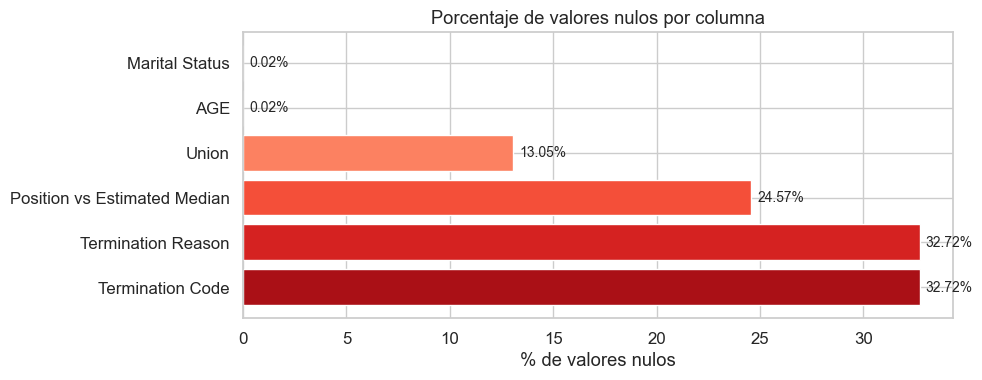

In [33]:
# --- Valores nulos ---
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Nulos': nulls,
    'Porcentaje (%)': nulls_pct,
    'Tipo': df.dtypes.astype(str)
}).sort_values('Porcentaje (%)', ascending=False)

print(f'Columnas sin nulos: {(nulls == 0).sum()} / {len(nulls)}')
print(f'Columnas con al menos 1 nulo: {(nulls > 0).sum()} / {len(nulls)}')
print()
print('--- Detalle de columnas con nulos ---')
display(null_df[null_df['Nulos'] > 0])

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
cols_con_nulos = null_df[null_df['Nulos'] > 0]
bars = ax.barh(cols_con_nulos.index, cols_con_nulos['Porcentaje (%)'], color=sns.color_palette('Reds_r', len(cols_con_nulos)))
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores nulos por columna')
for bar, val in zip(bars, cols_con_nulos['Porcentaje (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [34]:
# --- Duplicados ---
dupes_total = df.duplicated().sum()
dupes_emp   = df.duplicated(subset='Employee Code').sum()

print(f'Filas duplicadas (todas las columnas): {dupes_total}')
print(f'Employee Codes duplicados:             {dupes_emp}')
print(f'Employee Codes únicos:                 {df["Employee Code"].nunique():,} / {len(df):,}')

Filas duplicadas (todas las columnas): 0
Employee Codes duplicados:             0
Employee Codes únicos:                 5,792 / 5,792


In [35]:
# Únicos de cada columna
cardinality = pd.DataFrame({
    'Valores únicos': df.nunique(),
    '% únicos': (df.nunique() / len(df) * 100).round(2),
    'Tipo': df.dtypes,
    'Muestra': [str(df[c].dropna().unique()[:5].tolist()) for c in df.columns]
}).sort_values('Valores únicos', ascending=False)

print('CANTIDAD VALORES ÚNICOS POR COLUMNA')
print('='*60)
cardinality

CANTIDAD VALORES ÚNICOS POR COLUMNA


,Valores únicos,% únicos,Tipo,Muestra
Employee Code,5792,100.0000,object,"['EMP_00001', 'EMP_00002', 'EMP_00003', 'EMP_0..."
Termination Date,2123,36.6500,object,"[datetime.datetime(2013, 9, 27, 0, 0), datetim..."
Hire Date,1634,28.2100,datetime64[ns],"[Timestamp('2011-06-20 00:00:00'), Timestamp('..."
Exchange Rate,1484,25.6200,float64,"[3001.5, 3765.92, 3698.6, 2987.57, 3088.44]"
Standardized_Salary,840,14.5000,float64,"[0.1556099603024481, 0.09053202751327347, 0.17..."
Position vs Estimated Median,694,11.9800,float64,"[0.828, 1.249653305263158, 1.0121811208642808,..."
Supervisor Code,354,6.1100,object,"['Inactive', 'EMP_01989', 'EMP_00185', 'EMP_00..."
Employee Job ID,341,5.8900,object,"['Cargo 1', 'Cargo 2', 'Cargo 3', 'Cargo 4', '..."
Supervisor Job ID,130,2.2400,object,"['Cargo 342', 'Cargo 37', 'Cargo 13', 'Cargo 9..."
AGE,48,0.8300,float64,"[33.0, 38.0, 29.0, 27.0, 32.0]"


---
## 4. Análisis variable por variable (las 40 columnas)

Se documenta cada variable: tipo, distribución, observaciones y relevancia para el modelo.

Variable 1: Employee Code: No aporta valor predictivo — es una llave primaria. Podría usarse para calcular el número de jefes distintos, pero no como feature directa.

Variable 2: Termination Code: 
→ Altamente correlacionado con Termination Reason. Puede descartarse si se usa Termination Reason.
→ NaN indica empleado activo (dato implícito, no faltante real).

VARIABLE 3 — Hours/Week
             count
Hours/ Week       
48            2932
44            2018
46             356
47             333
24             110
23              22
22              10
0                8
36               1
8                1
40               1

  Media: 45.8 | Mín: 0 | Máx: 48


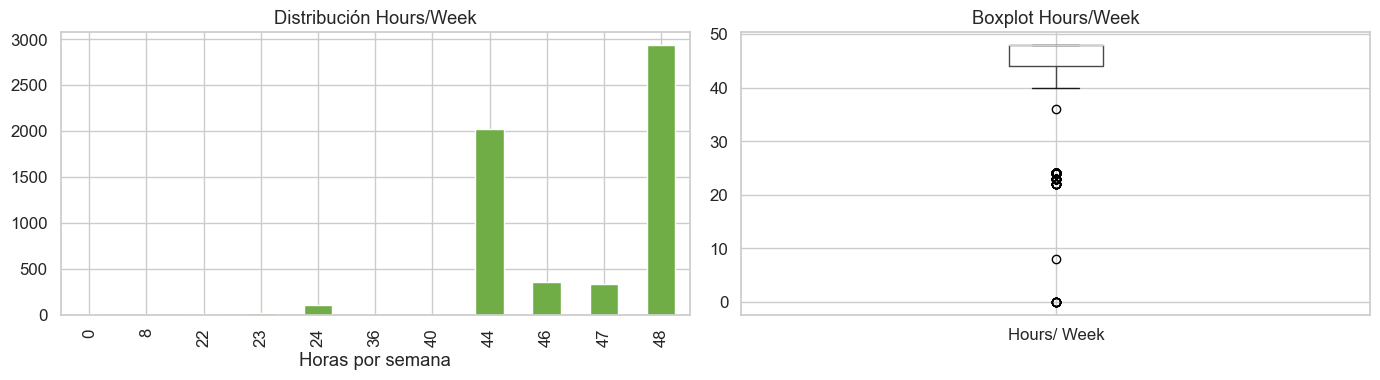

In [39]:
# ── Variable 3: Hours/Week ─────────────────────────────────────────────────
print('VARIABLE 3 — Hours/Week')
print(df['Hours/ Week'].value_counts().to_frame('count'))
print()
print(f'  Media: {df["Hours/ Week"].mean():.1f} | Mín: {df["Hours/ Week"].min()} | Máx: {df["Hours/ Week"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Hours/ Week'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución Hours/Week')
axes[0].set_xlabel('Horas por semana')
df.boxplot(column='Hours/ Week', ax=axes[1])
axes[1].set_title('Boxplot Hours/Week')
plt.tight_layout()
plt.show()

Variable 3: Los que tienen horas en 0, son errores en datos, se debe revisar que acción se va a tomar, los del rango inferior a 44, se debe revisar que sean personas part time, de lo contrario, tambien seria error en el registro y debe tratarse

Variable 4: Currency Code: Desde la abse se dejaron todos los registros en moneda local COP, por lo que hay un error en las monedas que parecen como USD, seria una variable a eliminar porque seria única, no aporta valor, es la misma para todos

VARIABLES 5, 6, 7 — Niveles de Inglés (Reading, Spoken, Writing)
       English Reading Lvl  English Spoken Lvl  English Writing Lvl
count            5792.0000           5792.0000            5792.0000
mean                0.6221              0.6117               0.6269
std                 1.2394              1.2289               1.2477
min                 0.0000              0.0000               0.0000
25%                 0.0000              0.0000               0.0000
50%                 0.0000              0.0000               0.0000
75%                 1.0000              1.0000               1.0000
max                 4.0000              4.0000               4.0000


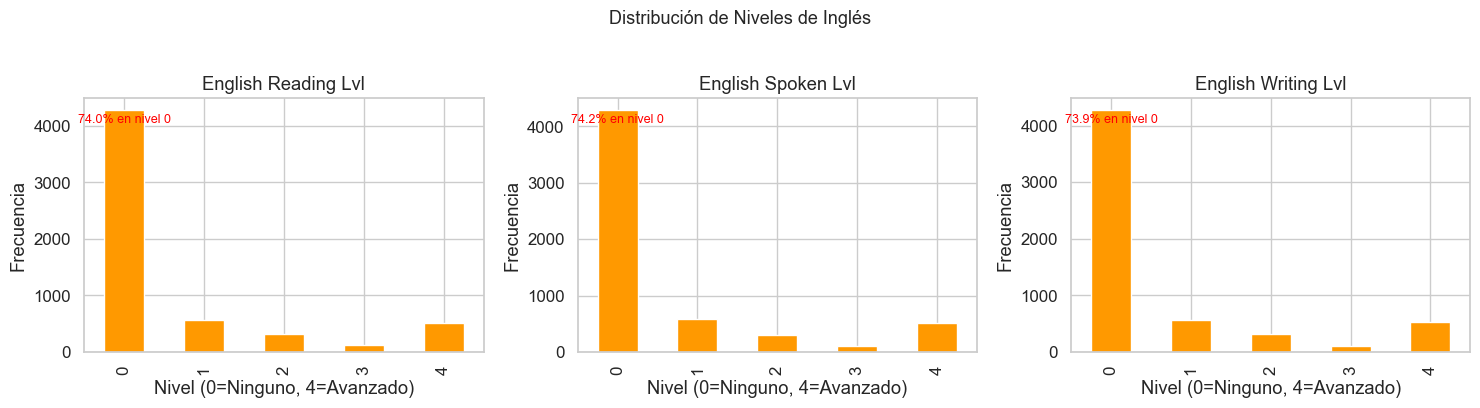

In [41]:
# ── Variables 5-7: Niveles de inglés ──────────────────────────────────────
english_cols = ['English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl']

print('VARIABLES 5, 6, 7 — Niveles de Inglés (Reading, Spoken, Writing)')
print(df[english_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, english_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#ff9900')
    ax.set_title(col)
    ax.set_xlabel('Nivel (0=Ninguno, 4=Avanzado)')
    pct_cero = (df[col] == 0).mean() * 100
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'{pct_cero:.1f}% en nivel 0', xy=(0, ax.get_ylim()[1]*0.9), ha='center', fontsize=9, color='red')
plt.suptitle('Distribución de Niveles de Inglés', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Variables 5-7: Niveles de inglés
→ Alta correlación entre las 3 variables → considerar crear un índice compuesto: english_score.
→ Mayoría en nivel 0 (empresa hispanohablante) → baja varianza predictiva por sí solas.

VARIABLES 8, 9, 10 — Niveles de Español (Reading, Spoken, Writing)
       Spanish Reading Lvl  Spanish Spoken Lvl  Spanish Writing Lvl
count            5792.0000           5792.0000            5792.0000
mean                3.0570              3.0566               3.0471
std                 1.6872              1.6875               1.6919
min                 0.0000              0.0000               0.0000
25%                 4.0000              4.0000               4.0000
50%                 4.0000              4.0000               4.0000
75%                 4.0000              4.0000               4.0000
max                 4.0000              4.0000               4.0000


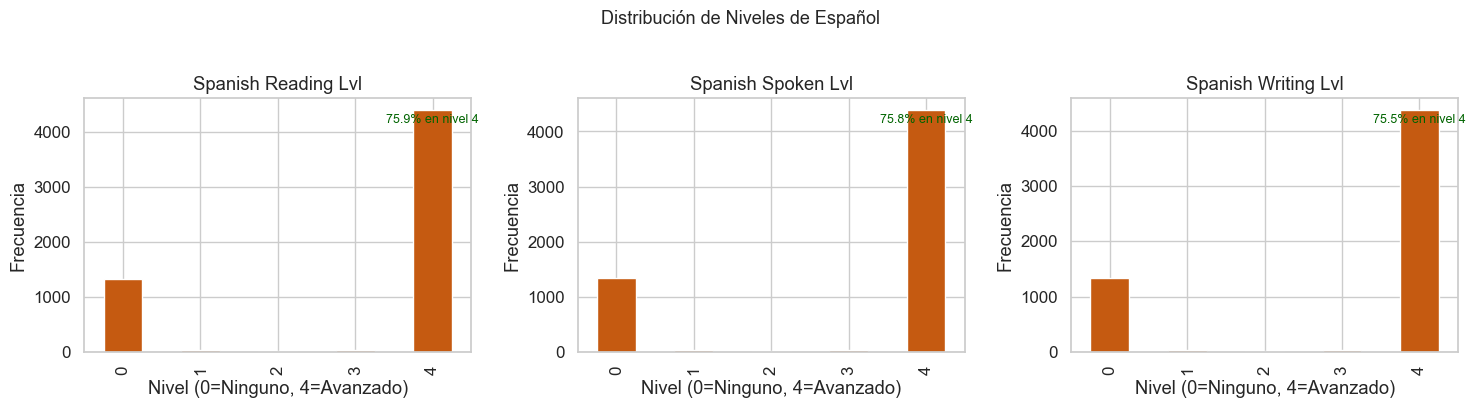

In [43]:
# ── Variables 8-10: Niveles de español ────────────────────────────────────
spanish_cols = ['Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl']

print('VARIABLES 8, 9, 10 — Niveles de Español (Reading, Spoken, Writing)')
print(df[spanish_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, spanish_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#c55a11')
    ax.set_title(col)
    ax.set_xlabel('Nivel (0=Ninguno, 4=Avanzado)')
    pct_cuatro = (df[col] == 4).mean() * 100
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'{pct_cuatro:.1f}% en nivel 4', xy=(4, ax.get_ylim()[1]*0.9), ha='center', fontsize=9, color='darkgreen')
plt.suptitle('Distribución de Niveles de Español', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Variables 8-10: Niveles de español

→ Altísima correlación inter-variable → crear índice compuesto: spanish_score.
→ Mayoría en nivel 4 (empresa en Colombia) → baja varianza individual, creo que no aporta mucho valor al modelo, entonces podriamos quitarlo, hay gente que no tiene buen nivel de español, porque son personas de otras nacionalidades, pero en su mayoria se trata de personas que dominan el idioma, creo que puede ser más interesante el dominar el inglés que el español

In [46]:
# ── Variable 11: Union ────────────────────────────────────────────────────
print('VARIABLE 11 — Union')
print(df['Union'].value_counts(dropna=False))
print()


VARIABLE 11 — Union
Union
N      5030
NaN     756
Y         5
X         1
Name: count, dtype: int64



Variable 11: Union 
"N": significa que no están en el sindicanto y representa el 99.9% de los registros con valor.
Nulos: 756 (13.1%)
Varianza extremadamente baja (casi todos "N") → candidata a eliminación.

VARIABLE 12 — Employee Job ID
  Únicos: 341
  Top 10:
Employee Job ID
Cargo 31    621
Cargo 39    462
Cargo 17    440
Cargo 29    201
Cargo 36    180
Cargo 6     174
Cargo 43    148
Cargo 38    137
Cargo 15    128
Cargo 64    121
Name: count, dtype: int64


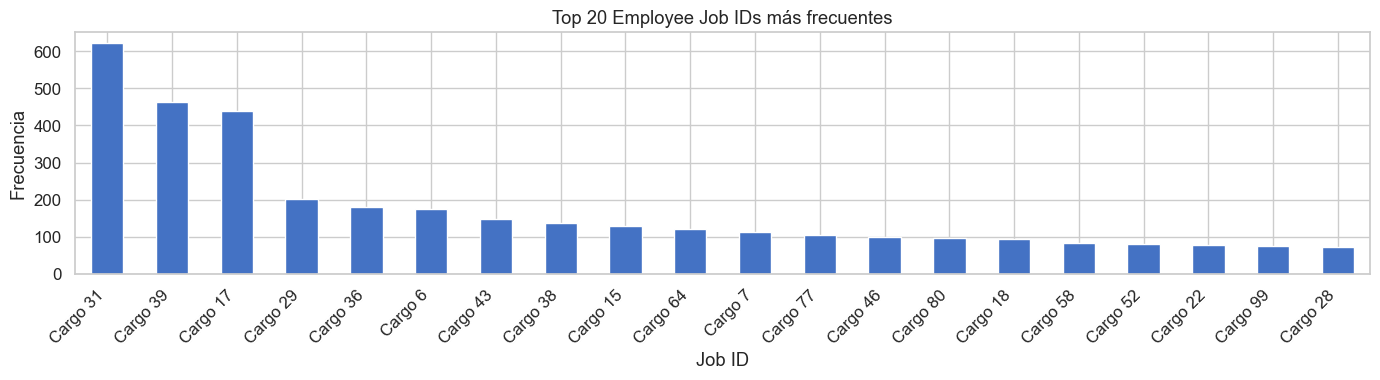

In [50]:
# ── Variable 12: Employee Job ID ──────────────────────────────────────────
print('VARIABLE 12 — Employee Job ID')
print(f'  Únicos: {df["Employee Job ID"].nunique()}')
print(f'  Top 10:')
print(df['Employee Job ID'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(14, 4))
top_jobs = df['Employee Job ID'].value_counts().head(20)
top_jobs.plot(kind='bar', ax=ax, color='#4472c4')
ax.set_title('Top 20 Employee Job IDs más frecuentes')
ax.set_xlabel('Job ID')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()

Variable 12: Employee Job ID: Este se refiere a los diferentes cargos que existen en la empresa, por temas de confidencialidad se codificaron, por ejemplo cajero ahora aparece como Cargo 31, por decir algo.
→ Alta cantidad de valores únicos (341 cargos). Revisar si quizá pueda agruparse con otra variable por ejemplo segun el departamento
→ Podría codificarse con target encoding o frecuency encoding

VARIABLE 13 — Gender
Gender
Male       3482
Female     2289
Unknown      21
Name: count, dtype: int64


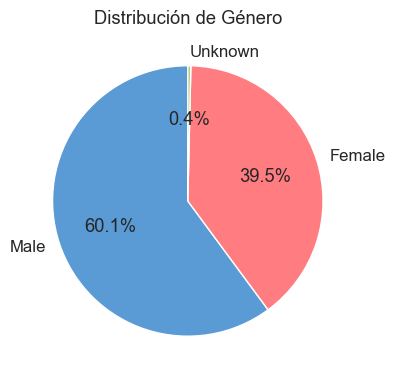

In [49]:
# ── Variable 13: Gender ───────────────────────────────────────────────────
print('VARIABLE 13 — Gender')
print(df['Gender'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(6, 4))
vals = df['Gender'].value_counts()
ax.pie(vals, labels=vals.index, autopct='%1.1f%%', startangle=90,
       colors=['#5b9bd5', '#ff7c80', '#a9d18e'])
ax.set_title('Distribución de Género')
plt.tight_layout()
plt.show()

Variable 13: Gender 
  21 registros "Unknown" (0.36%) → revisar si hay que imputar o mantener como categoría.
  → Variable relevante para análisis de equidad y para el modelo.

VARIABLE 14 — Marital Status
Marital Status
Single        3510
Free Union    1105
Married        792
Common Law     173
Unknown        126
Divorced        77
Widowed          5
Partner          3
NaN              1
Name: count, dtype: int64


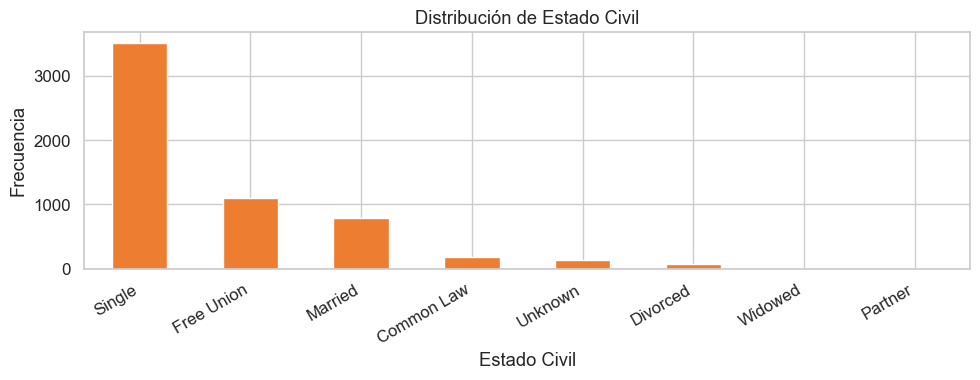

In [52]:
# ── Variable 14: Marital Status ───────────────────────────────────────────
print('VARIABLE 14 — Marital Status')
print(df['Marital Status'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
df['Marital Status'].value_counts().plot(kind='bar', ax=ax, color='#ed7d31')
ax.set_title('Distribución de Estado Civil')
ax.set_xlabel('Estado Civil')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print()


Variable 14: Marital Status
→ "Common Law" y "Free Union" son similares jurídicamente; considerar unificar.
→ 1 nulo → imputar con moda o categoría "Unknown".

VARIABLES 15, 16 — Area y Grouped Department Name


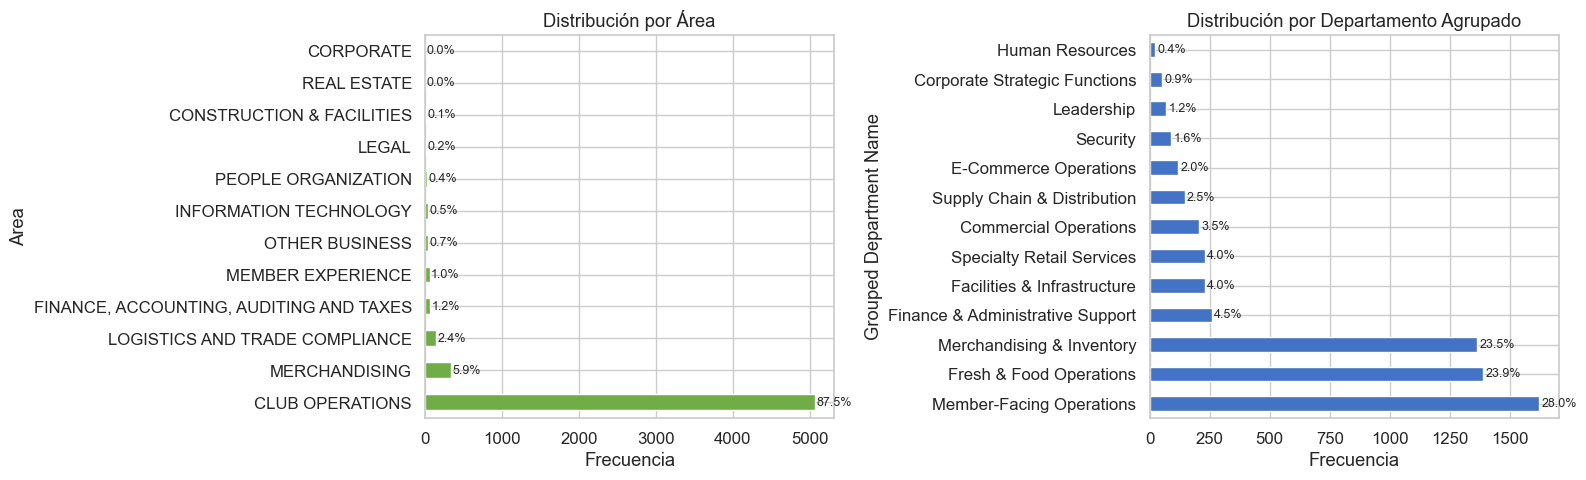

In [54]:
# ── Variables 15-16: Area y Grouped Department Name ──────────────────────
print('VARIABLES 15, 16 — Area y Grouped Department Name')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

area_counts = df['Area'].value_counts()
area_counts.plot(kind='barh', ax=axes[0], color='#70ad47')
axes[0].set_title('Distribución por Área')
axes[0].set_xlabel('Frecuencia')
for i, v in enumerate(area_counts):
    axes[0].text(v + 20, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

dept_counts = df['Grouped Department Name'].value_counts()
dept_counts.plot(kind='barh', ax=axes[1], color='#4472c4')
axes[1].set_title('Distribución por Departamento Agrupado')
axes[1].set_xlabel('Frecuencia')
for i, v in enumerate(dept_counts):
    axes[1].text(v + 10, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print()

VARIABLE 17 — Job Level
Job Level
1     1244
2     1739
3      739
4      767
5      645
6      162
7      351
8       69
9       26
10      34
11      10
12       2
13       2
15       1
16       1
Name: count, dtype: int64


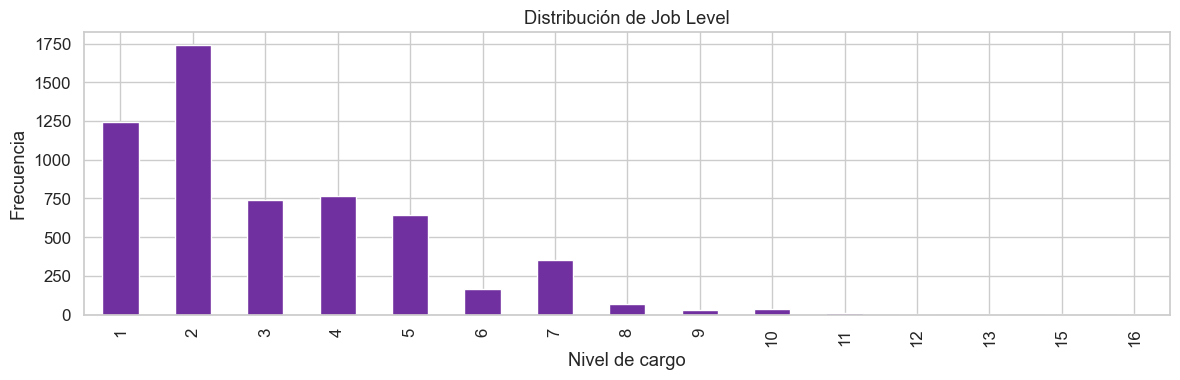

In [57]:
# ── Variable 17: Job Level ────────────────────────────────────────────────
print('VARIABLE 17 — Job Level')
print(df['Job Level'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(12, 4))
df['Job Level'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#7030a0')
ax.set_title('Distribución de Job Level')
ax.set_xlabel('Nivel de cargo')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


 Variable 17: Job Level
 puede llegar a ser muy importante en el modelo (nivel de cargo vs rotación). Se puede considerar agruar bajo categorias de técnico, tecnologo, profesional, jefes, etc.

VARIABLES 18, 19 — Location Description y Type Location


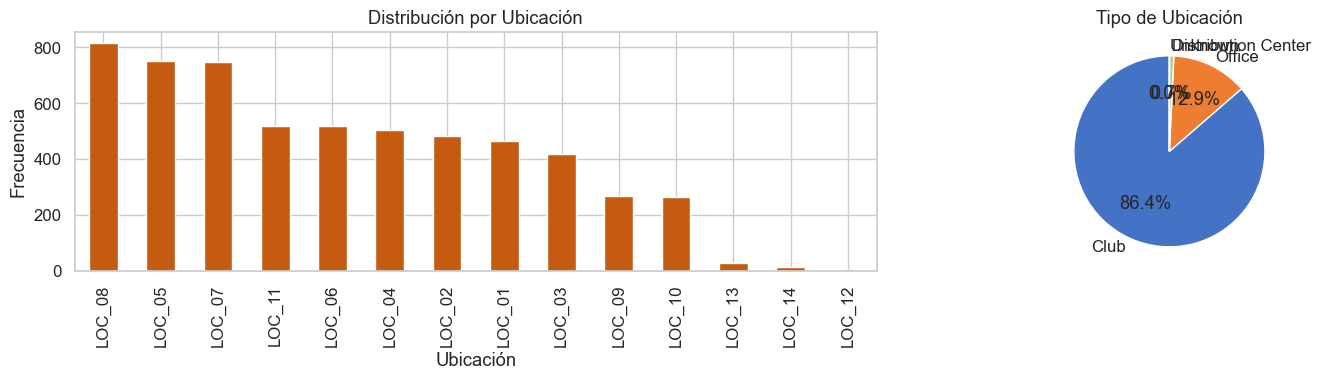

Type Location        Type   
Club                 C          5003
Distribution Center  D            42
Office               O           746
Unknown              Unknown       1


In [59]:
# ── Variables 18-19: Location Description y Type Location ─────────────────
print('VARIABLES 18, 19 — Location Description y Type Location')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

loc_counts = df['Location Description'].value_counts()
loc_counts.plot(kind='bar', ax=axes[0], color='#c55a11')
axes[0].set_title('Distribución por Ubicación')
axes[0].set_xlabel('Ubicación')
axes[0].set_ylabel('Frecuencia')

type_loc_counts = df['Type Location'].value_counts()
axes[1].pie(type_loc_counts, labels=type_loc_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31', '#a9d18e', '#ffc000'])
axes[1].set_title('Tipo de Ubicación')

plt.tight_layout()
plt.show()

print(df.groupby('Type Location')['Type'].value_counts().to_string())

Variables 18-19: Location Description y Type Location
→ Type Location y la columna "Type" son redundantes (C=Club, O=Office, D=Distribution).
→ Verificar cruce

VARIABLE 20 — Contract Type
Contract Type
Full Time    5590
Part Time     202
Name: count, dtype: int64

VARIABLE 21 — Exchange Rate (TRM USD/COP)
count   5792.0000
mean    3695.4444
std      457.4823
min     2705.7500
25%     3421.0550
50%     3765.9200
75%     3909.5125
max     5104.0000
Name: Exchange Rate, dtype: float64


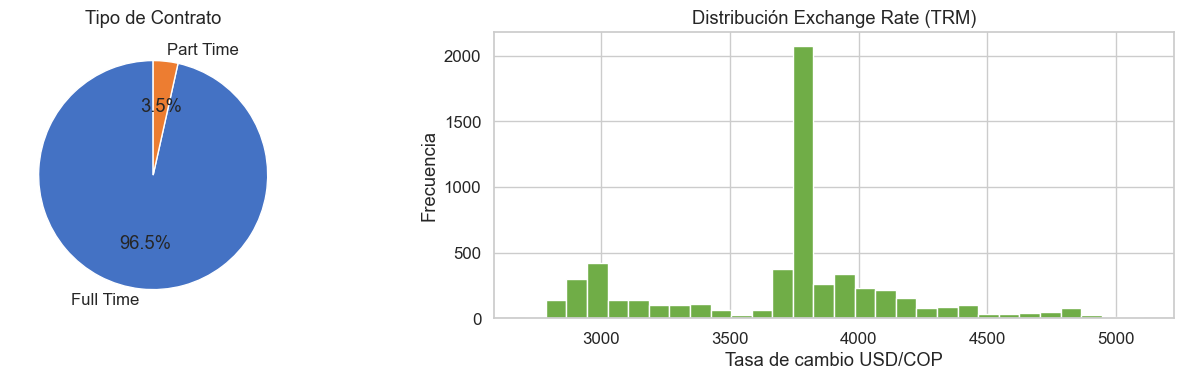

In [61]:
# ── Variables 20-21: Contract Type y Exchange Rate ─────────────────────────
print('VARIABLE 20 — Contract Type')
print(df['Contract Type'].value_counts())
print()
print('VARIABLE 21 — Exchange Rate (TRM USD/COP)')
print(df['Exchange Rate'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_counts = df['Contract Type'].value_counts()
axes[0].pie(ct_counts, labels=ct_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31'])
axes[0].set_title('Tipo de Contrato')

df['Exchange Rate'].hist(bins=30, ax=axes[1], color='#70ad47', edgecolor='white')
axes[1].set_title('Distribución Exchange Rate (TRM)')
axes[1].set_xlabel('Tasa de cambio USD/COP')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Variables 20-21: Contract Type y Exchange Rate
Contract Type: mayoría Full Time (96.5%).
Exchange Rate: varía entre 2,700 y 5,100 → refleja cambio en el tiempo (ligado a Hire Date)
→ Exchange Rate = TRM a la fecha de contratación; correlacionada con Hire Date.

VARIABLE 22 — Type
Type
C          5003
O           746
D            42
Unknown       1
Name: count, dtype: int64

VARIABLE 23 — Termination Reason
  Nulos: 1895 (empleados activos)
Termination Reason
Better Job Opp (Voluntary)        663
Other **EXPLAIN IN COMMENTS**     407
Family (Voluntary)                399
Personal** DO NOT USE** (Vol)     367
Violation of Policy (Involun)     296
Reduction in Force (Involun)      283
Unable to meet job requirement    275
Unwilling to meet job req.        205
Unwilling to meet req (Inv)       169
Relocation(Voluntary)             152
Insubordination (Involuntary)     123
Unknown (Voluntary)               108
School (Voluntary)                 83
Boredom (Voluntary)                71
Work Environment (Voluntary)       55
Name: count, dtype: int64

VARIABLE 24 — Termination Type
Termination Type
Voluntary      2021
Unknown        1895
Involuntary    1876
Name: count, dtype: int64


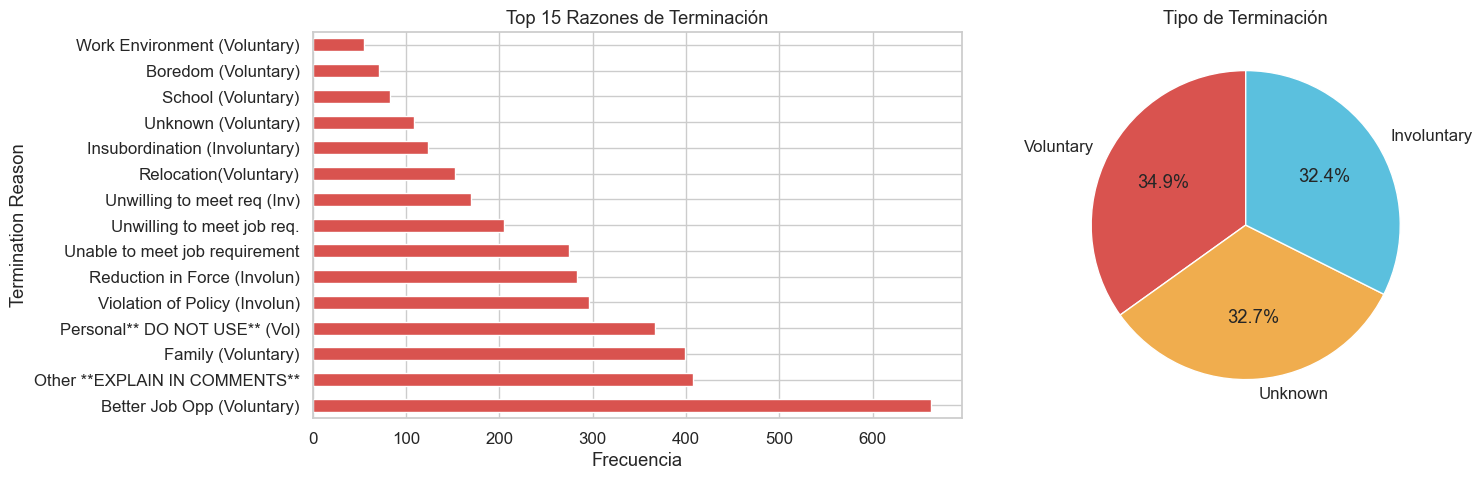

In [63]:
# ── Variables 22-24: Type, Termination Reason, Termination Type ──────────
print('VARIABLE 22 — Type')
print(df['Type'].value_counts())
print()
print('VARIABLE 23 — Termination Reason')
print(f'  Nulos: {df["Termination Reason"].isnull().sum()} (empleados activos)')
print(df['Termination Reason'].value_counts().head(15))
print()
print('VARIABLE 24 — Termination Type')
print(df['Termination Type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Termination Reason - solo retirados
term_reason = df[df['Termination Reason'].notna()]['Termination Reason'].value_counts().head(15)
term_reason.plot(kind='barh', ax=axes[0], color='#d9534f')
axes[0].set_title('Top 15 Razones de Terminación')
axes[0].set_xlabel('Frecuencia')

# Termination Type
tt_counts = df['Termination Type'].value_counts()
axes[1].pie(tt_counts, labels=tt_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#d9534f', '#f0ad4e', '#5bc0de'])
axes[1].set_title('Tipo de Terminación')

plt.tight_layout()
plt.show()

Variables 22-24: Type, Termination Reason, Termination Type
"Unknown" en Termination Type = empleados activos (1,895 registros).')
→ Termination Reason tiene 34 categorías — agrupar en: Voluntaria, Involuntaria, Desconocida.')
→ "Type" (C/O/D/Unknown) duplica Type Location → candidata a eliminación.')

VARIABLE 25 — Target Bonus %
count   5792.0000
mean       0.0043
std        0.0271
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        0.3000
Name: Target Bonus %, dtype: float64
  Cero: 5647 registros (97.5%)

VARIABLE 30 — Target Equity %
count   5792.0000
mean       0.0017
std        0.0159
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        0.4000
Name: Target Equity %, dtype: float64
  Cero: 5716 registros (98.7%)


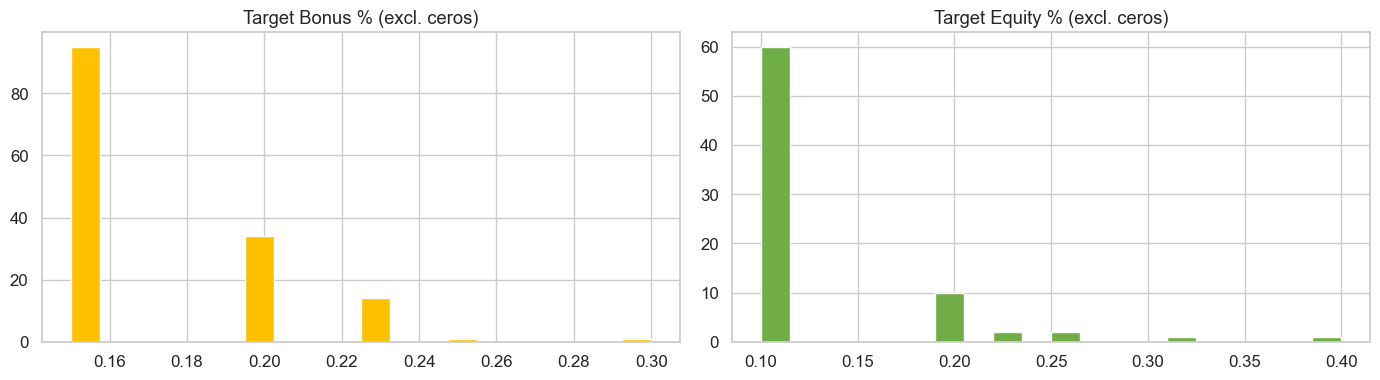

In [64]:
# ── Variables 25, 30: Target Bonus % y Target Equity % ───────────────────
print('VARIABLE 25 — Target Bonus %')
print(df['Target Bonus %'].describe())
print(f'  Cero: {(df["Target Bonus %"] == 0).sum()} registros ({(df["Target Bonus %"] == 0).mean()*100:.1f}%)')
print()
print('VARIABLE 30 — Target Equity %')
print(df['Target Equity %'].describe())
print(f'  Cero: {(df["Target Equity %"] == 0).sum()} registros ({(df["Target Equity %"] == 0).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[df['Target Bonus %'] > 0]['Target Bonus %'].hist(bins=20, ax=axes[0], color='#ffc000', edgecolor='white')
axes[0].set_title('Target Bonus % (excl. ceros)')
df[df['Target Equity %'] > 0]['Target Equity %'].hist(bins=20, ax=axes[1], color='#70ad47', edgecolor='white')
axes[1].set_title('Target Equity % (excl. ceros)')
plt.tight_layout()
plt.show()


Variables 25, 30: Target Bonus % y Target Equity %: Se refiere al % de bono anual que recibiria una persona si aplica (Target bonus) y al % de bono variable de una persona si aplica.
→ Crear variables binarias: has_bonus y has_equity para mejor representación.

VARIABLE 26 — Non Exempt (exento de horas extras)
Non Exempt
Non Exempt    2905
Exempt        2887
Name: count, dtype: int64

VARIABLE 27 — Active Employee (VARIABLE OBJETIVO)
Active Employee
N    3897
Y    1895
Name: count, dtype: int64
  Tasa de rotación: 67.3%


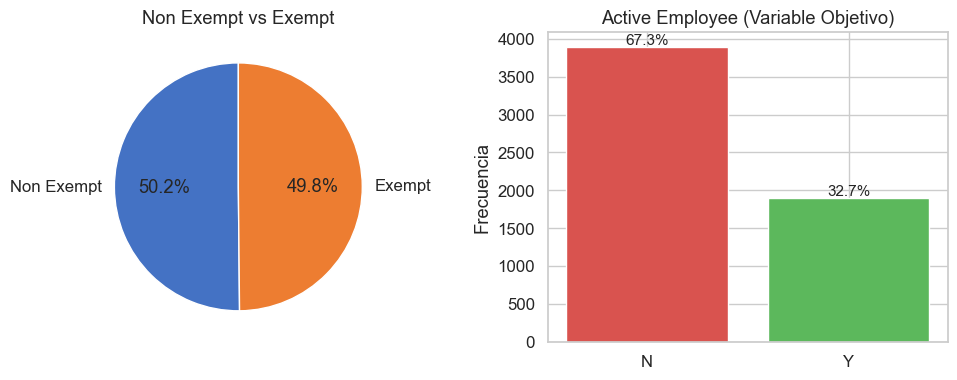

In [66]:
# ── Variables 26, 27: Non Exempt y Active Employee ─────────────────────────
print('VARIABLE 26 — Non Exempt (exento de horas extras)')
print(df['Non Exempt'].value_counts())
print()
print('VARIABLE 27 — Active Employee (VARIABLE OBJETIVO)')
print(df['Active Employee'].value_counts())
print(f'  Tasa de rotación: {(df["Active Employee"] == "N").mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ne_counts = df['Non Exempt'].value_counts()
axes[0].pie(ne_counts, labels=ne_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4472c4', '#ed7d31'])
axes[0].set_title('Non Exempt vs Exempt')

ae_counts = df['Active Employee'].value_counts()
axes[1].bar(ae_counts.index, ae_counts.values, color=['#d9534f', '#5cb85c'])
axes[1].set_title('Active Employee (Variable Objetivo)')
axes[1].set_ylabel('Frecuencia')
for i, (k, v) in enumerate(ae_counts.items()):
    axes[1].text(i, v + 30, f'{v/len(df)*100:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Variables 26, 27: Non Exempt y Active Employee
→ Active Employee = N: son los que han rotado
→ Dataset con clases relativamente balanceadas.

En cuantyo a Exempt y Non Exempt, se refiere a si las personas está habilitadas para generar horas extras y recibir pago de ello

VARIABLE 28 — Hire Date
  Rango: 1998-11-02 a 2025-12-19
  Tipo: datetime64[ns]

VARIABLE 29 — Termination Date
  Tipo raw: datetime64[ns]
  Valores únicos (muestra): <DatetimeArray>
['2013-09-27 00:00:00',                 'NaT', '2014-08-27 00:00:00',
 '2013-04-15 00:00:00', '2015-07-09 00:00:00', '2014-10-15 00:00:00',
 '2014-02-18 00:00:00', '2013-06-01 00:00:00', '2013-07-22 00:00:00',
 '2014-02-15 00:00:00']
Length: 10, dtype: datetime64[ns]
  Nulos tras conversión: 1895


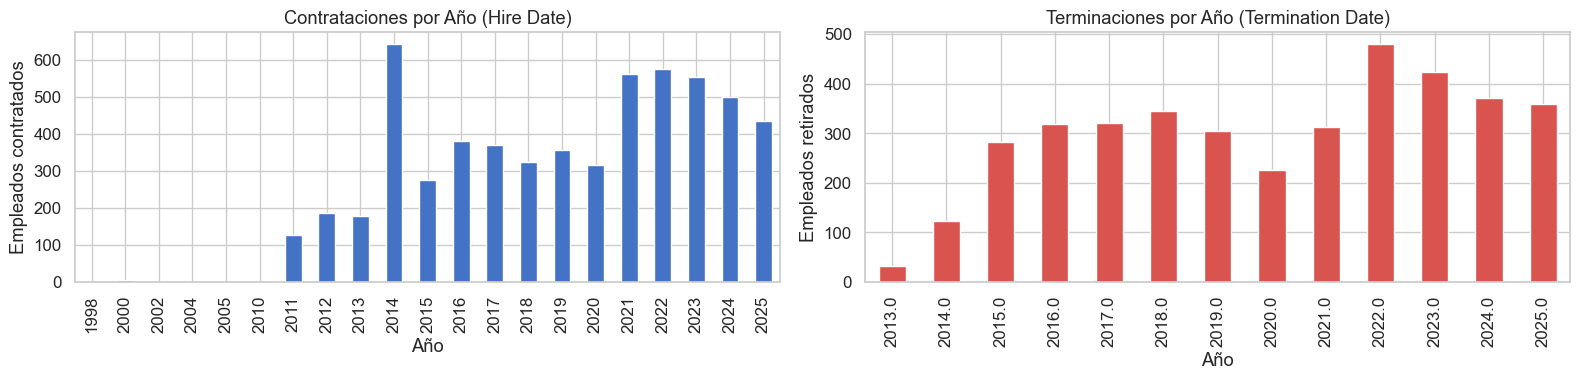

In [67]:
# ── Variables 28, 29: Hire Date y Termination Date ────────────────────────
print('VARIABLE 28 — Hire Date')
print(f'  Rango: {df["Hire Date"].min().date()} a {df["Hire Date"].max().date()}')
print(f'  Tipo: {df["Hire Date"].dtype}')

print()
print('VARIABLE 29 — Termination Date')
print(f'  Tipo raw: {df["Termination Date"].dtype}')
print(f'  Valores únicos (muestra): {df["Termination Date"].unique()[:10]}')

# Convertir Termination Date
df['Termination Date Clean'] = pd.to_datetime(df['Termination Date'], errors='coerce')
# Valores que son solo hora '00:00:00' corresponden a empleados activos
print(f'  Nulos tras conversión: {df["Termination Date Clean"].isnull().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df['Hire Date'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4472c4')
axes[0].set_title('Contrataciones por Año (Hire Date)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Empleados contratados')

df['Termination Date Clean'].dt.year.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#d9534f')
axes[1].set_title('Terminaciones por Año (Termination Date)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Empleados retirados')

plt.tight_layout()
plt.show()


Variables 28, 29: Hire Date y Termination Date
→ Hire Date está limpio (datetime64). Termination Date tiene mezcla de fechas y timestamps vacíos.
→ Ambas son clave para calcular ANTIGÜEDAD. y si pasó o no el periodo de prueba, hau una vaiable que lo indica, pero se debe validar que esté boien (periodo de prueba 2 meses)

VARIABLE 31 — Standardized_Salary
count   5792.0000
mean       0.0000
std        1.0000
min       -0.4802
25%       -0.3060
50%       -0.1810
75%       -0.0502
max       43.4621
Name: Standardized_Salary, dtype: float64

  Media ≈ 0, Std ≈ 1 → ya está estandarizada (Z-score).
  Mínimo: -0.480 | Máximo: 43.462
  Outliers (|z| > 3): 92 registros


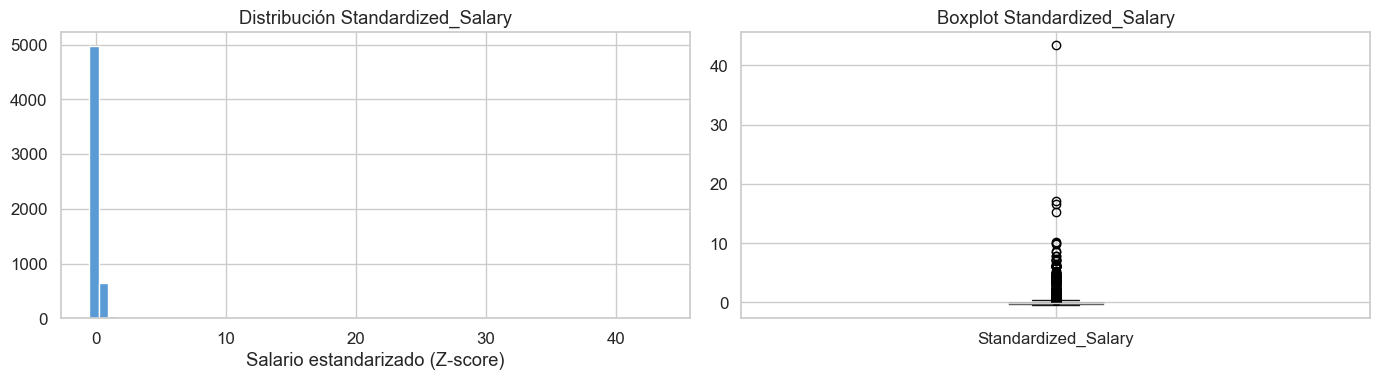

In [68]:
# ── Variable 31: Standardized_Salary ──────────────────────────────────────
print('VARIABLE 31 — Standardized_Salary')
print(df['Standardized_Salary'].describe())
print()
print(f'  Media ≈ 0, Std ≈ 1 → ya está estandarizada (Z-score).')
print(f'  Mínimo: {df["Standardized_Salary"].min():.3f} | Máximo: {df["Standardized_Salary"].max():.3f}')
print(f'  Outliers (|z| > 3): {(df["Standardized_Salary"].abs() > 3).sum()} registros')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Standardized_Salary'].hist(bins=60, ax=axes[0], color='#5b9bd5', edgecolor='white')
axes[0].set_title('Distribución Standardized_Salary')
axes[0].set_xlabel('Salario estandarizado (Z-score)')
df.boxplot(column='Standardized_Salary', ax=axes[1])
axes[1].set_title('Boxplot Standardized_Salary')
plt.tight_layout()
plt.show()


Variable 31: Standardized_Salary
→ Distribución sesgada a la derecha (unos pocos ejecutivos con salarios muy altos).
→ Variable predictiva clave: salario relativo vs rotación.

In [69]:
# ── Variables 32-35: Datos del Supervisor ────────────────────────────────
print('VARIABLES 32-35 — Supervisor (Active Supervisor, Code, Dept, Job ID)')
print()
print('Active Supervisor:')
print(df['Active Supervisor'].value_counts())
print()
print('Supervisor Code (top 10):')
print(df['Supervisor Code'].value_counts().head(10))
print()
print('Gropued Supervisor Department:')
print(df['Gropued Supervisor Department'].value_counts())
print()
print('Supervisor Job ID (top 10):')
print(df['Supervisor Job ID'].value_counts().head(10))


VARIABLES 32-35 — Supervisor (Active Supervisor, Code, Dept, Job ID)

Active Supervisor:
Active Supervisor
Y    3924
N    1868
Name: count, dtype: int64

Supervisor Code (top 10):
Supervisor Code
Inactive     1868
EMP_01768     113
EMP_01553      84
EMP_02410      72
EMP_00980      67
EMP_01352      64
EMP_00185      59
EMP_00013      59
EMP_00431      58
EMP_01000      56
Name: count, dtype: int64

Gropued Supervisor Department:
Gropued Supervisor Department
Inactive                            1868
Member-Facing Operations             749
Leadership                           739
Merchandising & Inventory            664
Fresh & Food Operations              644
Finance & Administrative Support     229
Other / Non-Operational              222
Commercial Operations                194
Supply Chain & Distribution          117
Facilities & Infrastructure           96
Corporate Strategic Functions         89
Specialty Retail Services             53
E-Commerce Operations                 50
Hum

Variables 32-35: Datos del Supervisor
→ Supervisor Code tiene valor "Inactive" cuando el supervisor ya no está activo (1,868 casos).
→ Active Supervisor Y/N puede ser relevante: tener un jefe activo vs. inactivo.
→ Supervisor Code tiene alta cardinalidad (354 únicos) — usar Active Supervisor o Dept del supervisor.

In [70]:
# ── Variable 36: Probation Period Completed ───────────────────────────────
print('VARIABLE 36 — Probation Period Completed')
print(df['Probation Period Completed'].value_counts())
pct_yes = (df['Probation Period Completed'] == 'Yes').mean() * 100


VARIABLE 36 — Probation Period Completed
Probation Period Completed
Yes    5743
No       49
Name: count, dtype: int64


Variable 36: Probation Period Completed
Esta es la variable que idgo que hay que revisar con detalle, a partir de la fecha de contratación y terminación, porque puede estar mal

VARIABLE 37 — Position vs Estimated Median
count   4369.0000
mean       0.9616
std        2.3237
min        0.3440
25%        0.8436
50%        0.9166
75%        0.9596
max      154.2114
Name: Position vs Estimated Median, dtype: float64
  Nulos: 1423 (24.6%)


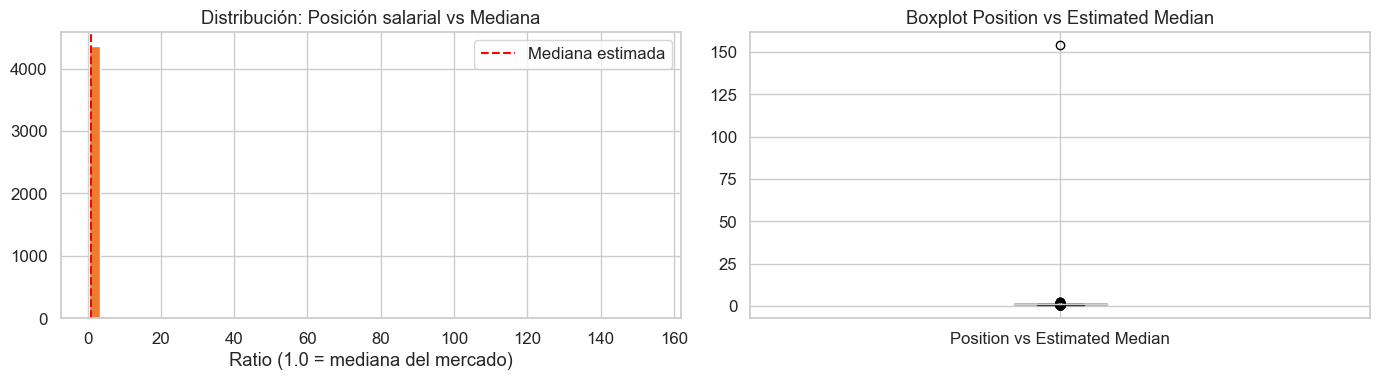


  → 39.1% de nulos — posiblemente cargos sin referencia de mercado disponible.
  → Variable muy relevante: qué tan competitivo es el salario vs el mercado.
  → personas debajo de 1.0 → sugiere que muchos empleados ganan por debajo de la mediana de mercado.
  → es una banda salarial, que va del 80% ¨(piso de la banda), al 120% (techo de la banda).


In [72]:
# ── Variable 37: Position vs Estimated Median ─────────────────────────────
print('VARIABLE 37 — Position vs Estimated Median')
print(df['Position vs Estimated Median'].describe())
print(f'  Nulos: {df["Position vs Estimated Median"].isnull().sum()} ({df["Position vs Estimated Median"].isnull().mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Position vs Estimated Median'].hist(bins=50, ax=axes[0], color='#ed7d31', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', label='Mediana estimada')
axes[0].set_title('Distribución: Posición salarial vs Mediana')
axes[0].set_xlabel('Ratio (1.0 = mediana del mercado)')
axes[0].legend()
df.boxplot(column='Position vs Estimated Median', ax=axes[1])
axes[1].set_title('Boxplot Position vs Estimated Median')
plt.tight_layout()
plt.show()

print()
print('  → 39.1% de nulos — posiblemente cargos sin referencia de mercado disponible.')
print('  → Variable muy relevante: qué tan competitivo es el salario vs el mercado.')
print('  → personas debajo de 1.0 → sugiere que muchos empleados ganan por debajo de la mediana de mercado.')
print('  → es una banda salarial, que va del 80% ¨(piso de la banda), al 120% (techo de la banda).')

VARIABLE 38 — AGE
count   5791.0000
mean      31.4763
std        7.4749
min        0.0000
25%       26.0000
50%       30.0000
75%       36.0000
max       67.0000
Name: AGE, dtype: float64
  Nulos: 1

VARIABLE 39 — CPI (Índice de Precios al Consumidor)
count   5792.0000
mean       0.0580
std        0.0269
min        0.0161
25%        0.0510
50%        0.0510
75%        0.0575
max        0.1312
Name: CPI, dtype: float64
  Únicos: 13

VARIABLE 40 — Minimum Wage (Salario Mínimo en COP)
count      5792.0000
mean    1104431.3983
std      302192.8304
min      589500.0000
25%      828116.0000
50%     1160000.0000
75%     1423500.0000
max     1423500.0000
Name: Minimum wage, dtype: float64
  Únicos: 13 (uno por año)


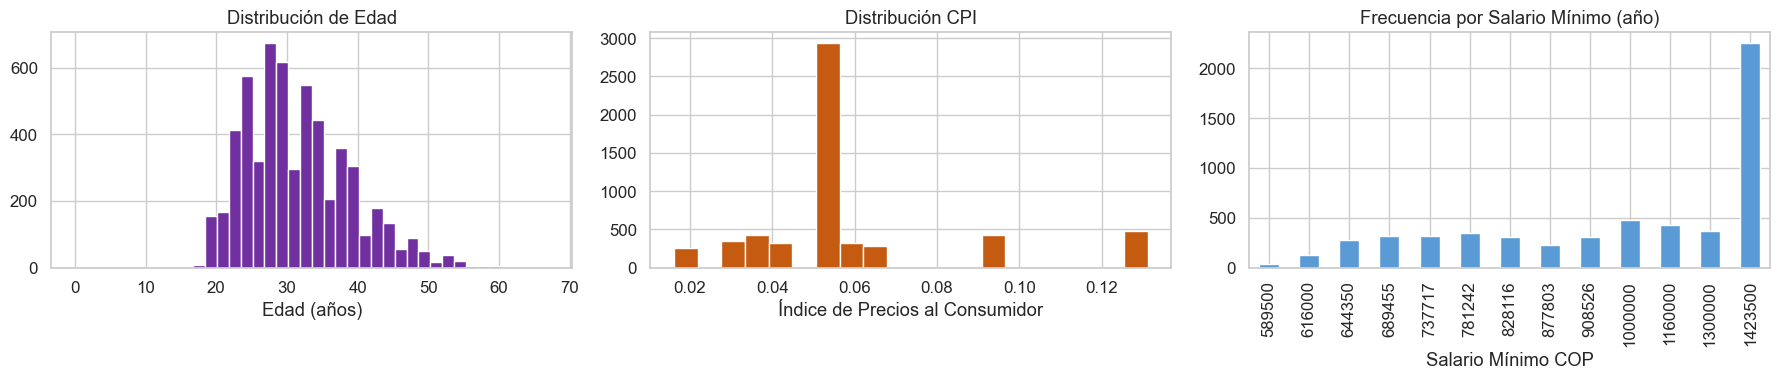

In [73]:
# ── Variables 38-40: AGE, CPI y Minimum Wage ──────────────────────────────
print('VARIABLE 38 — AGE')
print(df['AGE'].describe())
print(f'  Nulos: {df["AGE"].isnull().sum()}')
print()
print('VARIABLE 39 — CPI (Índice de Precios al Consumidor)')
print(df['CPI'].describe())
print(f'  Únicos: {df["CPI"].nunique()}')
print()
print('VARIABLE 40 — Minimum Wage (Salario Mínimo en COP)')
print(df['Minimum wage'].describe())
print(f'  Únicos: {df["Minimum wage"].nunique()} (uno por año)')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df['AGE'].hist(bins=40, ax=axes[0], color='#7030a0', edgecolor='white')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad (años)')

df['CPI'].hist(bins=20, ax=axes[1], color='#c55a11', edgecolor='white')
axes[1].set_title('Distribución CPI')
axes[1].set_xlabel('Índice de Precios al Consumidor')

df['Minimum wage'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#5b9bd5')
axes[2].set_title('Frecuencia por Salario Mínimo (año)')
axes[2].set_xlabel('Salario Mínimo COP')

plt.tight_layout()
plt.show()

Para la edad, podemos hacer agrupaciones: centenials, milenials, boomers, etc.

---
## 4. Este era el paso de creación de varibale nuevas

In [36]:
# Convertir fechas
df['Hire Date'] = pd.to_datetime(df['Hire Date'], errors='coerce')
df['Termination Date'] = pd.to_datetime(df['Termination Date'], errors='coerce')

# Limpiar 'Termination Code' y 'Termination Reason': reemplazar 'nan' string
for col in ['Termination Code', 'Termination Reason', 'Termination Type']:
    df[col] = df[col].replace('nan', np.nan)

# Variable de rotación (target): el empleado dejó la empresa
df['Turnover'] = df['Active Employee'].map({'N': 1, 'Y': 0})

# Antigüedad en días y años
reference_date = pd.Timestamp('2024-01-01')  # fecha de referencia
df['Tenure_Days'] = np.where(
    df['Turnover'] == 1,
    (df['Termination Date'] - df['Hire Date']).dt.days,
    (reference_date - df['Hire Date']).dt.days
)
df['Tenure_Years'] = (df['Tenure_Days'] / 365.25).round(2)

# Año de contratación
df['Hire_Year'] = df['Hire Date'].dt.year

# Año de terminación (solo para los que se fueron)
df['Termination_Year'] = df['Termination Date'].dt.year
df.loc[df['Turnover'] == 0, 'Termination_Year'] = np.nan

# Nivel de inglés promedio
eng_cols = ['English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl']
df['English_Avg'] = df[eng_cols].mean(axis=1).round(2)

# Nivel de español promedio
spa_cols = ['Spanish Reading Lvl', 'Spanish Spoken Lvl', 'Spanish Writing Lvl']
df['Spanish_Avg'] = df[spa_cols].mean(axis=1).round(2)

# Limpiar 'Position vs Estimated Median' — convertir porcentaje a numérico
df['Position_vs_Median'] = df['Position vs Estimated Median'].astype(str).str.replace('%', '').str.strip()
df['Position_vs_Median'] = pd.to_numeric(df['Position_vs_Median'], errors='coerce')

# Rangos de edad
df['Age_Group'] = pd.cut(df['AGE'], bins=[18, 25, 30, 35, 40, 45, 50, 55, 60, 100],
                         labels=['18-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '60+'])

# Tenure buckets
df['Tenure_Group'] = pd.cut(df['Tenure_Years'], bins=[-1, 1, 3, 5, 8, 12, 50],
                            labels=['<1 año', '1-3 años', '3-5 años', '5-8 años', '8-12 años', '12+ años'])

print(f'Variables derivadas creadas. Nuevo shape: {df.shape}')
print(f'Distribución de Turnover: \n{df["Turnover"].value_counts()}')
df[['Employee Code', 'Turnover', 'Tenure_Years', 'Hire_Year', 'English_Avg', 'Age_Group', 'Tenure_Group']].head(10)

Variables derivadas creadas. Nuevo shape: (5792, 50)
Distribución de Turnover: 
Turnover
1    3897
0    1895
Name: count, dtype: int64


,Employee Code,Turnover,Tenure_Years,Hire_Year,English_Avg,Age_Group,Tenure_Group
0,EMP_00001,1,2.2700,2011,3.0000,31-35,1-3 años
1,EMP_00002,0,12.4700,2011,0.0000,36-40,12+ años
2,EMP_00003,1,3.1300,2011,0.0000,26-30,3-5 años
3,EMP_00004,1,0.8800,2012,2.0000,26-30,<1 año
4,EMP_00005,1,3.1100,2012,0.0000,31-35,3-5 años
5,EMP_00006,1,2.3400,2012,0.0000,31-35,1-3 años
6,EMP_00007,1,1.6900,2012,0.0000,18-25,1-3 años
7,EMP_00008,1,0.9700,2012,2.0000,18-25,<1 año
8,EMP_00009,1,1.1100,2012,1.0000,31-35,1-3 años
9,EMP_00010,0,11.5600,2012,0.3300,46-50,8-12 años


---
## 5. Análisis univariado — Variables categóricas

In [ ]:
# Variables categóricas clave
cat_cols = ['Gender', 'Marital Status', 'Area', 'Grouped Department Name', 
            'Type Location', 'Contract Type', 'Type', 'Non Exempt', 
            'Active Employee', 'Union', 'Probation Period Completed']

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data = df[col].value_counts().head(10)
    bars = axes[i].barh(data.index.astype(str), data.values, color=sns.color_palette('viridis', len(data)))
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Frecuencia')
    for bar, val in zip(bars, data.values):
        axes[i].text(bar.get_width() + max(data.values)*0.01, bar.get_y() + bar.get_height()/2,
                    f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

# Ocultar ejes sobrantes
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Distribución detallada de departamentos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dept = df['Grouped Department Name'].value_counts()
axes[0].barh(dept.index, dept.values, color=sns.color_palette('Set2', len(dept)))
axes[0].set_title('Distribución por Departamento', fontweight='bold')
axes[0].set_xlabel('Cantidad de empleados')
for i, (val, name) in enumerate(zip(dept.values, dept.index)):
    axes[0].text(val + 10, i, f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

# Distribución de Job Level
jl = df['Job Level'].value_counts().sort_index()
axes[1].bar(jl.index.astype(str), jl.values, color=sns.color_palette('coolwarm', len(jl)))
axes[1].set_title('Distribución por Job Level', fontweight='bold')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Cantidad de empleados')
for x, val in zip(jl.index.astype(str), jl.values):
    axes[1].text(x, val + 10, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Distribución de razones de terminación (solo empleados que salieron)
terminated = df[df['Turnover'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Termination Type
tt = terminated['Termination Type'].value_counts()
axes[0].pie(tt.values, labels=tt.index, autopct='%1.1f%%', startangle=90,
           colors=sns.color_palette('Set2', len(tt)))
axes[0].set_title('Tipo de Terminación', fontweight='bold')

# Top 10 Termination Reasons
tr = terminated['Termination Reason'].value_counts().head(10)
axes[1].barh(tr.index, tr.values, color=sns.color_palette('Reds_r', len(tr)))
axes[1].set_title('Top 10 Razones de Terminación', fontweight='bold')
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
# Distribución de ubicaciones
loc = df['Location Description'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(loc.index.astype(str), loc.values, color=sns.color_palette('viridis', len(loc)))
ax.set_title('Top 15 Ubicaciones', fontweight='bold')
ax.set_xlabel('Ubicación')
ax.set_ylabel('Cantidad de empleados')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, loc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Análisis univariado — Variables numéricas

In [ ]:
num_cols = ['Hours/ Week', 'AGE', 'Standardized_Salary', 'Target Bonus %', 
            'Target Equity %', 'Exchange Rate', 'English_Avg', 'Spanish_Avg',
            'Tenure_Years', 'Position_vs_Median', 'Job Level']

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='green', linestyle='-.', linewidth=1.5, label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas (Histogramas)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, vert=True, patch_artist=True, 
                         boxprops=dict(facecolor='lightblue', color='navy'),
                         medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontweight='bold')
    
    # Calcular outliers con IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'Outliers: {outliers} ({outliers/len(data)*100:.1f}%)', fontsize=9)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Detección de Outliers', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen de outliers
outlier_summary = []
for col in num_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lím. Inferior': round(Q1 - 1.5*IQR, 2),
        'Lím. Superior': round(Q3 + 1.5*IQR, 2),
        'N Outliers': n_outliers,
        '% Outliers': round(n_outliers / len(data) * 100, 2),
        'Skewness': round(data.skew(), 2),
        'Kurtosis': round(data.kurtosis(), 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print('RESUMEN DE OUTLIERS Y FORMA DE DISTRIBUCIÓN')
print('='*80)
outlier_df

---
## 7. Análisis bivariado

In [ ]:
# Turnover por variables categóricas clave
cat_vs_turnover = ['Gender', 'Marital Status', 'Grouped Department Name', 'Non Exempt',
                   'Type Location', 'Age_Group', 'Tenure_Group', 'Probation Period Completed']

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(cat_vs_turnover):
    ct = pd.crosstab(df[col], df['Turnover'], normalize='index') * 100
    ct.columns = ['Activo', 'Salió']
    ct.sort_values('Salió', ascending=True).plot(kind='barh', stacked=True, ax=axes[i],
                                                  color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Tasa de Rotación por {col}', fontweight='bold')
    axes[i].set_xlabel('Porcentaje (%)')
    axes[i].legend(loc='lower right')
    axes[i].set_xlim(0, 100)

plt.suptitle('Tasa de Rotación por Variables Categóricas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla de tasas de rotación por categoría
print('TASAS DE ROTACIÓN POR CATEGORÍA')
print('='*70)
for col in cat_vs_turnover:
    ct = df.groupby(col)['Turnover'].agg(['mean', 'count'])
    ct.columns = ['Tasa Rotación', 'N']
    ct['Tasa Rotación'] = (ct['Tasa Rotación'] * 100).round(1)
    ct = ct.sort_values('Tasa Rotación', ascending=False)
    print(f'\n--- {col} ---')
    display(ct)

In [ ]:
# Salary vs Turnover
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución de salario por turnover
for turnover_val, label, color in [(0, 'Activo', '#2ecc71'), (1, 'Salió', '#e74c3c')]:
    subset = df[df['Turnover'] == turnover_val]['Standardized_Salary'].dropna()
    axes[0, 0].hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0, 0].set_title('Distribución de Salario Estandarizado por Turnover', fontweight='bold')
axes[0, 0].set_xlabel('Standardized Salary')
axes[0, 0].legend()

# Edad vs Turnover
for turnover_val, label, color in [(0, 'Activo', '#2ecc71'), (1, 'Salió', '#e74c3c')]:
    subset = df[df['Turnover'] == turnover_val]['AGE'].dropna()
    axes[0, 1].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0, 1].set_title('Distribución de Edad por Turnover', fontweight='bold')
axes[0, 1].set_xlabel('Edad')
axes[0, 1].legend()

# Boxplot salario por turnover
df.boxplot(column='Standardized_Salary', by='Turnover', ax=axes[1, 0],
           patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('Salario por Turnover', fontweight='bold')
axes[1, 0].set_xticklabels(['Activo', 'Salió'])
axes[1, 0].set_xlabel('')
plt.sca(axes[1, 0])
plt.title('Salario por Turnover', fontweight='bold')

# Boxplot edad por turnover
df.boxplot(column='AGE', by='Turnover', ax=axes[1, 1],
           patch_artist=True, boxprops=dict(facecolor='lightyellow'))
axes[1, 1].set_title('Edad por Turnover', fontweight='bold')
axes[1, 1].set_xticklabels(['Activo', 'Salió'])
axes[1, 1].set_xlabel('')
plt.sca(axes[1, 1])
plt.title('Edad por Turnover', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Nivel de inglés vs Turnover y Job Level
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inglés vs Turnover
df.boxplot(column='English_Avg', by='Turnover', ax=axes[0], patch_artist=True)
axes[0].set_title('Nivel Inglés por Turnover', fontweight='bold')
axes[0].set_xticklabels(['Activo', 'Salió'])
axes[0].set_xlabel('')

# Salario por Job Level
df.boxplot(column='Standardized_Salary', by='Job Level', ax=axes[1], patch_artist=True)
axes[1].set_title('Salario por Job Level', fontweight='bold')
axes[1].set_xlabel('Job Level')

# Edad por departamento (top 6)
top_depts = df['Grouped Department Name'].value_counts().head(6).index
df_top = df[df['Grouped Department Name'].isin(top_depts)]
df_top.boxplot(column='AGE', by='Grouped Department Name', ax=axes[2], patch_artist=True)
axes[2].set_title('Edad por Departamento (Top 6)', fontweight='bold')
axes[2].set_xlabel('')
plt.sca(axes[2])
plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Salario promedio por departamento y turnover
salary_dept = df.groupby(['Grouped Department Name', 'Turnover'])['Standardized_Salary'].mean().unstack()
salary_dept.columns = ['Activo', 'Salió']
salary_dept = salary_dept.sort_values('Activo', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))
salary_dept.plot(kind='barh', ax=ax, color=['#2ecc71', '#e74c3c'], width=0.7)
ax.set_title('Salario Estandarizado Promedio por Departamento y Estado', fontweight='bold')
ax.set_xlabel('Salario Estandarizado Promedio')
ax.legend(title='Estado')
plt.tight_layout()
plt.show()

---
## 8. Análisis de correlaciones

In [ ]:
# Seleccionar variables numéricas para correlación
corr_cols = ['Hours/ Week', 'AGE', 'Standardized_Salary', 'Target Bonus %', 
             'Target Equity %', 'English_Avg', 'Spanish_Avg', 'Job Level',
             'Tenure_Years', 'Position_vs_Median', 'Turnover', 'Exchange Rate',
             'English Reading Lvl', 'English Spoken Lvl', 'English Writing Lvl']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Correlaciones más fuertes con Turnover
turnover_corr = corr_matrix['Turnover'].drop('Turnover').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in turnover_corr.values]
bars = ax.barh(turnover_corr.index, turnover_corr.values, color=colors)
ax.set_title('Correlación de variables con Turnover', fontweight='bold', fontsize=13)
ax.set_xlabel('Coeficiente de Correlación (Pearson)')
ax.axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, turnover_corr.values):
    ax.text(val + 0.005 if val > 0 else val - 0.04, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop correlaciones con Turnover:')
print(turnover_corr.to_string())

In [ ]:
# Scatterplots de las relaciones más interesantes
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Salario vs Job Level coloreado por Turnover
scatter1 = axes[0, 0].scatter(df['Job Level'], df['Standardized_Salary'], 
                               c=df['Turnover'], cmap='RdYlGn_r', alpha=0.3, s=10)
axes[0, 0].set_xlabel('Job Level')
axes[0, 0].set_ylabel('Standardized Salary')
axes[0, 0].set_title('Salario vs Job Level (color=Turnover)', fontweight='bold')

# Edad vs Salario
scatter2 = axes[0, 1].scatter(df['AGE'], df['Standardized_Salary'],
                               c=df['Turnover'], cmap='RdYlGn_r', alpha=0.3, s=10)
axes[0, 1].set_xlabel('Edad')
axes[0, 1].set_ylabel('Standardized Salary')
axes[0, 1].set_title('Edad vs Salario (color=Turnover)', fontweight='bold')

# Tenure vs Salario
scatter3 = axes[1, 0].scatter(df['Tenure_Years'], df['Standardized_Salary'],
                               c=df['Turnover'], cmap='RdYlGn_r', alpha=0.3, s=10)
axes[1, 0].set_xlabel('Antigüedad (años)')
axes[1, 0].set_ylabel('Standardized Salary')
axes[1, 0].set_title('Antigüedad vs Salario (color=Turnover)', fontweight='bold')

# Nivel de inglés vs Salario
scatter4 = axes[1, 1].scatter(df['English_Avg'], df['Standardized_Salary'],
                               c=df['Turnover'], cmap='RdYlGn_r', alpha=0.3, s=10)
axes[1, 1].set_xlabel('Nivel Inglés Promedio')
axes[1, 1].set_ylabel('Standardized Salary')
axes[1, 1].set_title('Inglés vs Salario (color=Turnover)', fontweight='bold')

for ax in axes.flatten():
    ax.legend(*scatter1.legend_elements(), labels=['Activo', 'Salió'], loc='upper left', fontsize=8)

plt.suptitle('Scatterplots — Relaciones clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Análisis temporal

In [ ]:
# Contrataciones por año
hire_year = df['Hire_Year'].value_counts().sort_index()

# Terminaciones por año (solo empleados que salieron)
term_year = df[df['Turnover'] == 1]['Termination_Year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(hire_year.index.astype(int), hire_year.values, color='steelblue', edgecolor='white')
axes[0].set_title('Contrataciones por Año', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
for x, y in zip(hire_year.index, hire_year.values):
    axes[0].text(x, y + 5, str(y), ha='center', fontsize=8)

axes[1].bar(term_year.index.astype(int), term_year.values, color='#e74c3c', edgecolor='white')
axes[1].set_title('Terminaciones por Año', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Cantidad')
for x, y in zip(term_year.index, term_year.values):
    axes[1].text(x, y + 3, str(int(y)), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Flujo neto: contrataciones - terminaciones por año
years = sorted(set(hire_year.index.astype(int)) | set(term_year.index.dropna().astype(int)))
flow = pd.DataFrame({'Año': years})
flow['Contrataciones'] = flow['Año'].map(dict(zip(hire_year.index.astype(int), hire_year.values))).fillna(0)
flow['Terminaciones'] = flow['Año'].map(dict(zip(term_year.index.dropna().astype(int), term_year.values))).fillna(0)
flow['Flujo Neto'] = flow['Contrataciones'] - flow['Terminaciones']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(flow['Año'], flow['Contrataciones'], 'o-', color='steelblue', linewidth=2, label='Contrataciones')
ax.plot(flow['Año'], flow['Terminaciones'], 'o-', color='#e74c3c', linewidth=2, label='Terminaciones')
ax.bar(flow['Año'], flow['Flujo Neto'], alpha=0.3,
       color=['green' if x >= 0 else 'red' for x in flow['Flujo Neto']], label='Flujo Neto')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('Flujo de Personal por Año', fontweight='bold', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de empleados')
ax.legend()
plt.tight_layout()
plt.show()

print('Flujo de personal:')
flow.set_index('Año')

In [ ]:
# Distribución de antigüedad
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por grupo de antigüedad
tenure_g = df['Tenure_Group'].value_counts().sort_index()
axes[0].bar(tenure_g.index.astype(str), tenure_g.values, color=sns.color_palette('Blues_d', len(tenure_g)))
axes[0].set_title('Distribución por Grupo de Antigüedad', fontweight='bold')
axes[0].set_xlabel('Antigüedad')
axes[0].set_ylabel('Empleados')
for i, (x, y) in enumerate(zip(tenure_g.index.astype(str), tenure_g.values)):
    axes[0].text(i, y + 10, str(y), ha='center')

# Antigüedad por turnover
df.boxplot(column='Tenure_Years', by='Turnover', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Antigüedad por Estado del Empleado', fontweight='bold')
axes[1].set_xticklabels(['Activo', 'Salió'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Años de antigüedad')

plt.tight_layout()
plt.show()

---
## 10. Análisis de rotación (Turnover) en profundidad

In [ ]:
# Tasa de rotación global
total = len(df)
activos = df['Turnover'].value_counts().get(0, 0)
salieron = df['Turnover'].value_counts().get(1, 0)

print('RESUMEN DE ROTACIÓN')
print('='*50)
print(f'Total empleados en el dataset:  {total}')
print(f'Empleados activos:              {activos} ({activos/total*100:.1f}%)')
print(f'Empleados que salieron:         {salieron} ({salieron/total*100:.1f}%)')
print(f'Tasa de rotación global:        {salieron/total*100:.1f}%')

# Por tipo de terminación
print(f'\nPor tipo de terminación:')
print('-'*50)
tt_counts = terminated['Termination Type'].value_counts()
for tipo, count in tt_counts.items():
    print(f'  {tipo}: {count} ({count/salieron*100:.1f}% de las salidas)')

In [ ]:
# Perfil comparativo: Activos vs. Salieron
comparison_cols = ['AGE', 'Standardized_Salary', 'Tenure_Years', 'Job Level',
                   'Hours/ Week', 'Target Bonus %', 'English_Avg', 'Position_vs_Median']

comparison = df.groupby('Turnover')[comparison_cols].agg(['mean', 'median', 'std']).round(3)
comparison.index = ['Activo', 'Salió']

print('PERFIL COMPARATIVO: ACTIVOS vs. SALIERON')
print('='*80)
comparison

In [ ]:
# Tasa de rotación por Job Level
jl_turnover = df.groupby('Job Level').agg(
    Total=('Turnover', 'count'),
    Salieron=('Turnover', 'sum'),
    Tasa_Rotacion=('Turnover', 'mean')
).round(3)
jl_turnover['Tasa_Rotacion'] = (jl_turnover['Tasa_Rotacion'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(jl_turnover.index.astype(str), jl_turnover['Tasa_Rotacion'], 
           color=sns.color_palette('YlOrRd', len(jl_turnover)))
axes[0].set_title('Tasa de Rotación por Job Level', fontweight='bold')
axes[0].set_xlabel('Job Level')
axes[0].set_ylabel('Tasa de Rotación (%)')
for x, y in zip(jl_turnover.index.astype(str), jl_turnover['Tasa_Rotacion']):
    axes[0].text(x, y + 0.5, f'{y}%', ha='center', fontsize=9)

# Rotación voluntaria vs involuntaria por Job Level
vol_inv = terminated.groupby(['Job Level', 'Termination Type']).size().unstack(fill_value=0)
vol_inv_pct = vol_inv.div(vol_inv.sum(axis=1), axis=0) * 100
vol_inv_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#f39c12', '#3498db'])
axes[1].set_title('Tipo de Terminación por Job Level', fontweight='bold')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend(title='Tipo', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Detalle:')
jl_turnover

In [ ]:
# Tasa de rotación por ubicación
loc_turnover = df.groupby('Location Description').agg(
    Total=('Turnover', 'count'),
    Salieron=('Turnover', 'sum'),
    Tasa_Rotacion=('Turnover', 'mean')
).round(3)
loc_turnover['Tasa_Rotacion'] = (loc_turnover['Tasa_Rotacion'] * 100).round(1)
loc_turnover = loc_turnover.sort_values('Tasa_Rotacion', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('YlOrRd', len(loc_turnover))
ax.barh(loc_turnover.index, loc_turnover['Tasa_Rotacion'], color=colors)
ax.set_title('Tasa de Rotación por Ubicación', fontweight='bold')
ax.set_xlabel('Tasa de Rotación (%)')
for i, (val, total) in enumerate(zip(loc_turnover['Tasa_Rotacion'], loc_turnover['Total'])):
    ax.text(val + 0.3, i, f'{val}% (n={total})', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Análisis de rotación temprana (primeros 2 años)
early_turnover = terminated[terminated['Tenure_Years'] <= 2]
print('ROTACIÓN TEMPRANA (≤ 2 años de antigüedad)')
print('='*60)
print(f'Empleados que salieron en los primeros 2 años: {len(early_turnover)} ({len(early_turnover)/salieron*100:.1f}% de todas las salidas)')
print(f'\nRazones principales de salida temprana:')
print(early_turnover['Termination Reason'].value_counts().head(10).to_string())
print(f'\nTipo de terminación en salidas tempranas:')
print(early_turnover['Termination Type'].value_counts().to_string())
print(f'\nDepartamentos con más salidas tempranas:')
print(early_turnover['Grouped Department Name'].value_counts().head(6).to_string())

---
## 11. Resumen de hallazgos clave

In [ ]:
print('='*70)
print('      RESUMEN EJECUTIVO — HALLAZGOS CLAVE DEL EDA')
print('='*70)

print(f'''
1. DIMENSIÓN DEL DATASET
   - {df.shape[0]} empleados, {df.shape[1]} variables
   - Employee Codes únicos: {df['Employee Code'].nunique()}

2. TASA DE ROTACIÓN
   - Tasa global: {salieron/total*100:.1f}%
   - Activos: {activos} | Salieron: {salieron}
   - Voluntarias: {terminated[terminated['Termination Type']=='Voluntary'].shape[0]} | Involuntarias: {terminated[terminated['Termination Type']=='Involuntary'].shape[0]}

3. PERFIL DEMOGRÁFICO
   - Edad promedio: {df['AGE'].mean():.1f} años (rango {df['AGE'].min()}-{df['AGE'].max()})
   - Género: {df['Gender'].value_counts().to_dict()}
   - Antigüedad promedio: {df['Tenure_Years'].mean():.1f} años

4. VARIABLES CLAVE ASOCIADAS AL TURNOVER
   (Correlaciones de Pearson con Turnover)
''')

for var, corr_val in turnover_corr.head(6).items():
    direction = '↑ más rotación' if corr_val > 0 else '↓ menos rotación'
    print(f'   - {var}: r={corr_val:.3f} ({direction})')

print(f'''
5. CALIDAD DE DATOS
   - Filas duplicadas: {dup_total}
   - Columnas con >10% nulos: {len(null_analysis[null_analysis["% Nulos"] > 10])}
   - Fechas inválidas (1900): presentes en Termination Date para activos

6. ALERTAS
   - Verificar registros con Employee Code duplicado
   - Las fechas de terminación "1900" son placeholders para empleados activos
   - La columna 'Position vs Estimated Median' tiene formato mixto (% como texto)
   - Algunas razones de terminación contienen texto inconsistente (e.g., "DO NOT USE")
''')
print('='*70)
print('Fin del Análisis Exploratorio de Datos')
print('='*70)